In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [8]:
# Setup
# Solver and simulation parameters
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [9]:
filename = lambda M: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [17]:
Moments_even = [4, 8, 12, 16, 20, 24]
Moments_odd = [5, 9, 13, 17, 21, 25]
x_vec, u0_vec, u1_vec, u2_vec, u3_vec, u4_vec = {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}

for M in Moments_even + Moments_odd:
    file = filename(M)
    x, u, _ = sol_final(file)
    if M in Moments_even:
        key = 'even'
    else:
        key = 'odd'
    x_vec[key].append(x)
    u0_vec[key].append(u[:,0])
    u1_vec[key].append(u[:,1])
    u2_vec[key].append(u[:,2])
    u3_vec[key].append(u[:,3])
    u4_vec[key].append(u[:,4])

In [19]:
u0_err, u1_err, u2_err, u3_err, u4_err = {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}
for M in Moments_even[:-1] + Moments_odd[:-1]:
    if M in Moments_even:
        key = 'even'
        i = Moments_even.index(M)
    else:
        key = 'odd'
        i = Moments_odd.index(M)
    x_coarse = x_vec[key][i]
    x_fine = x_vec[key][-1]
    
    u0_coarse_interp = interp1d(x_coarse, u0_vec[key][i], kind='linear', fill_value="extrapolate")
    u1_coarse_interp = interp1d(x_coarse, u1_vec[key][i], kind='linear', fill_value="extrapolate")
    u2_coarse_interp = interp1d(x_coarse, u2_vec[key][i], kind='linear', fill_value="extrapolate")
    u3_coarse_interp = interp1d(x_coarse, u3_vec[key][i], kind='linear', fill_value="extrapolate")
    u4_coarse_interp = interp1d(x_coarse, u4_vec[key][i], kind='linear', fill_value="extrapolate")
    
    u0_coarse_on_fine = u0_coarse_interp(x_fine)
    u1_coarse_on_fine = u1_coarse_interp(x_fine)
    u2_coarse_on_fine = u2_coarse_interp(x_fine)
    u3_coarse_on_fine = u3_coarse_interp(x_fine)
    u4_coarse_on_fine = u4_coarse_interp(x_fine)
    
    # Compute errors
    for norm in ['L1', 'L2']:
        if norm == 'L1':
            err_u0 = np.mean(np.abs(u0_vec[key][-1] - u0_coarse_on_fine))
            err_u1 = np.mean(np.abs(u1_vec[key][-1] - u1_coarse_on_fine))
            err_u2 = np.mean(np.abs(u2_vec[key][-1] - u2_coarse_on_fine))
            err_u3 = np.mean(np.abs(u3_vec[key][-1] - u3_coarse_on_fine))
            err_u4 = np.mean(np.abs(u4_vec[key][-1] - u4_coarse_on_fine))
        elif norm == 'L2':
            err_u0 = np.sqrt(np.mean((u0_vec[key][-1] - u0_coarse_on_fine)**2))
            err_u1 = np.sqrt(np.mean((u1_vec[key][-1] - u1_coarse_on_fine)**2))
            err_u2 = np.sqrt(np.mean((u2_vec[key][-1] - u2_coarse_on_fine)**2))
            err_u3 = np.sqrt(np.mean((u3_vec[key][-1] - u3_coarse_on_fine)**2))
            err_u4 = np.sqrt(np.mean((u4_vec[key][-1] - u4_coarse_on_fine)**2))

        u0_err[key][norm].append(err_u0)
        u1_err[key][norm].append(err_u1)
        u2_err[key][norm].append(err_u2)
        u3_err[key][norm].append(err_u3)
        u4_err[key][norm].append(err_u4)

/tmp/ipykernel_4965/3640232257.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


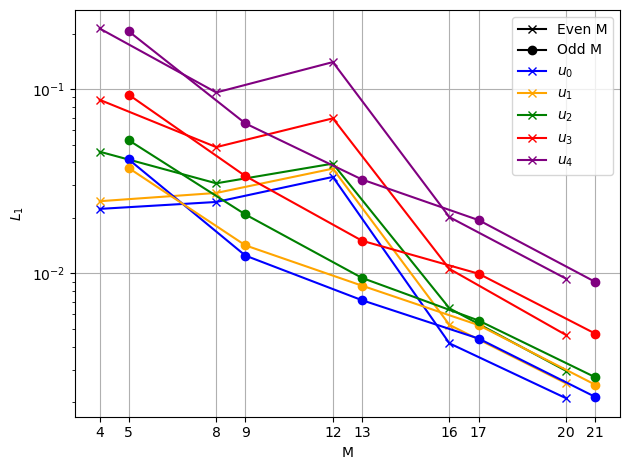

In [30]:
colors = ['blue', 'orange', 'green', 'red', 'purple']
markers = ['-x', '-o'] # even, odd

fig, axs = plt.subplots()
axs.plot([], [], markers[0], color='black', label='Even M')
axs.plot([], [], markers[1], color='black', label='Odd M')
for key in ['even', 'odd']:
    Moments = Moments_even if key == 'even' else Moments_odd
    marker = markers[0] if key == 'even' else markers[1]
    axs.semilogy(Moments[:-1], u0_err[key]['L1'], marker, color=colors[0], label=f'$u_0$' if key == 'even' else None)
    axs.semilogy(Moments[:-1], u1_err[key]['L1'], marker, color=colors[1], label=f'$u_1$' if key == 'even' else None)
    axs.semilogy(Moments[:-1], u2_err[key]['L1'], marker, color=colors[2], label=f'$u_2$' if key == 'even' else None)
    axs.semilogy(Moments[:-1], u3_err[key]['L1'], marker, color=colors[3], label=f'$u_3$' if key == 'even' else None)
    axs.semilogy(Moments[:-1], u4_err[key]['L1'], marker, color=colors[4], label=f'$u_4$' if key == 'even' else None)
axs.set_xticks(Moments_even[:-1] + Moments_odd[:-1])
axs.set_xlabel('M')
axs.set_ylabel('$L_1$')
axs.grid()
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/ModelConvergence/ModelConvergence_L1.pdf')
fig.show()